# MethylSeg Components Example

Use the assigner, analyzer, and segmentor directly after loading a saved pathway.

This example loads a packaged saved model so that the focus stays on the demonstrated operation.

In [1]:
from pathlib import Path

from methylseg import MethylSegPathway, MethylStateAssignmentMethod, MethylationStates
from methylseg.helper_classes import DATA_DIR

In [2]:
REFERENCE_DIR = DATA_DIR / "reference_files"
OUTPUT_ROOT = Path("out")
CHROM = "chr1"

RESOLUTION = "450k"
SAMPLE_NAME = "TCGA-BD-A3EP-01A"
SAMPLE_FILE = REFERENCE_DIR / "TCGA-BD-A3EP-01A_450k.tsv.gz"
OUT_DIR = OUTPUT_ROOT / "methylseg_components_example"

## Load a saved model and prepare the sample

In [3]:
model = MethylSegPathway.get_pretrained_model(
    out_dir=OUT_DIR,
    resolution=RESOLUTION,
)
sample_info, removed_df = MethylSegPathway.prepare_sample_info(
    sample_name=SAMPLE_NAME,
    sample_file=SAMPLE_FILE,
    resolution=RESOLUTION,
    min_coverage=10,
)
sample_info.sample_id

'TCGA-BD-A3EP-01A'

## Assigner

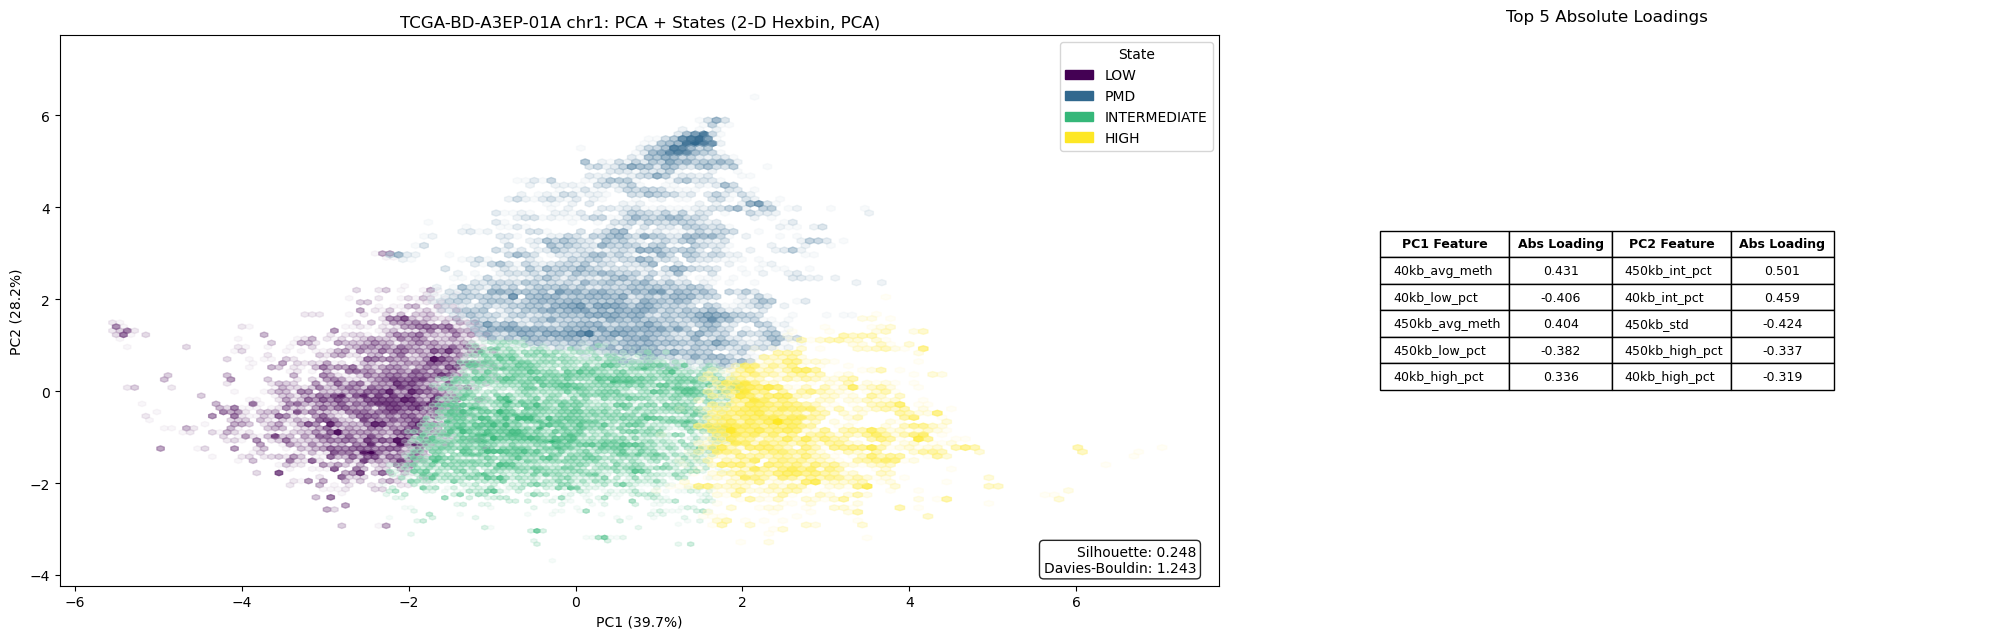

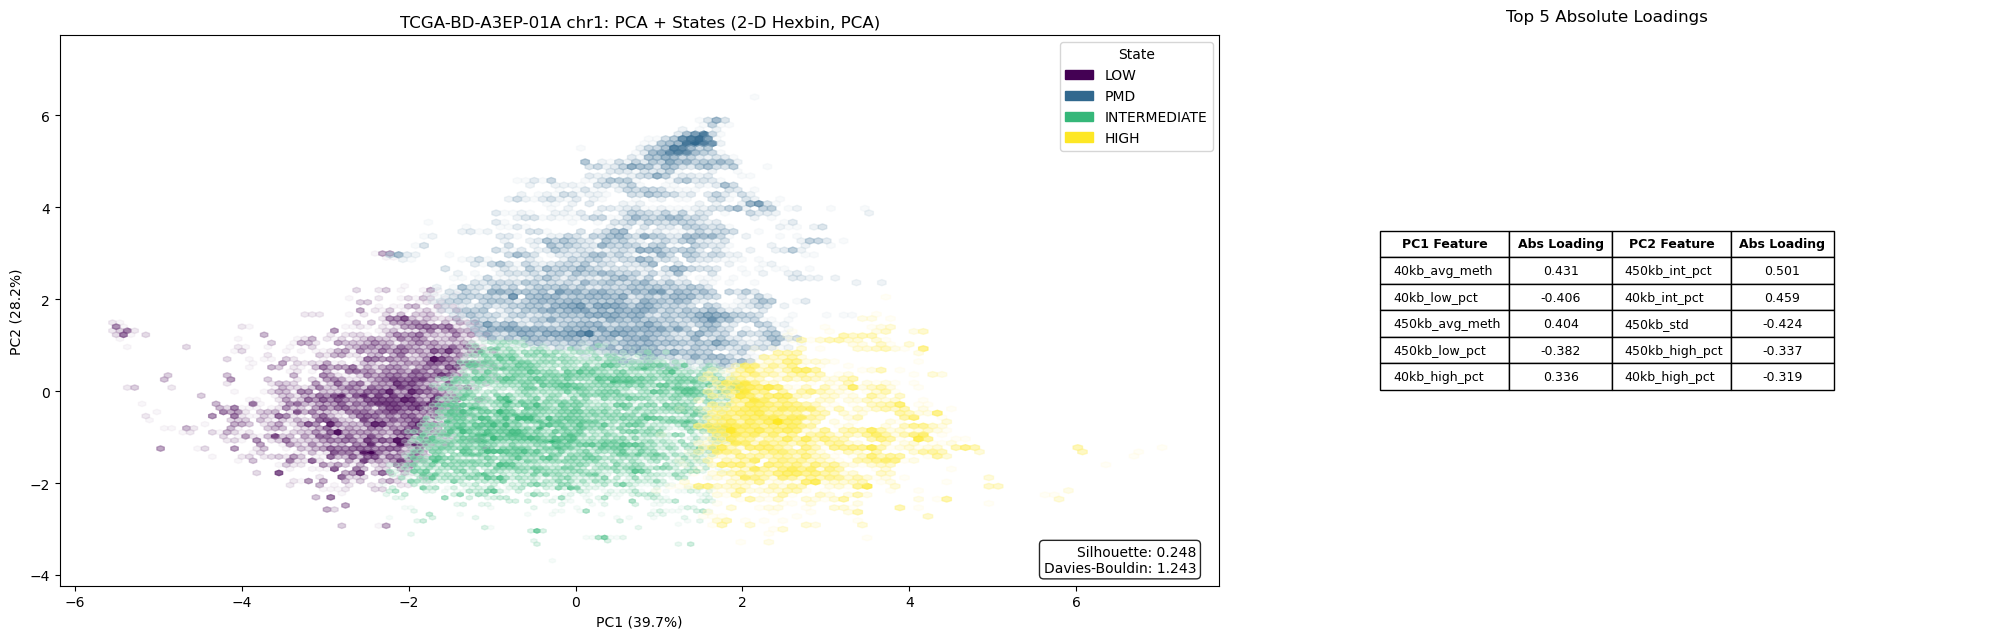

In [4]:
assigner = model.assigner
meth_data, emissions, pca_scores, _, _, labels = assigner.apply_kmeans_to_sample(
    sample_info=sample_info, chrom=CHROM
)
assigner.plot_embedding(
    emission_df=emissions, labels=labels, meth_data=meth_data, sample_info=sample_info,
    chrom=CHROM, method="pca", hexbin=True, hexbin_mincnt=1,
)

## Analyzer

In [5]:
rule_labels = model.analyzer.define_states_by_rules(
    sample_info=sample_info, chrom=CHROM, sample_emissions=emissions
)


## Segmentor

In [6]:
segmented_meth, _ = model.segmentor.segment_sample(sample_info=sample_info, chrom=CHROM)
regions_chr1 = model.segmentor.create_regions()
regions_chr1.head()

,CpG_chrm,start,end,avg_beta,probe_count,state
0,chr1,69590,859174,0.432264,53,PMD
1,chr1,859718,899435,0.504805,77,INTERMEDIATE
2,chr1,900423,931328,0.406957,46,PMD
3,chr1,933305,956300,0.463662,71,INTERMEDIATE
4,chr1,956798,990294,0.819857,70,HIGH
